In [ ]:
from google.colab import files
uploaded = files.upload()


Saving test.csv to test.csv
Saving train.csv to train.csv


Train shape: (891, 12)
Test shape : (418, 11)

Missing values in train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

── Model Performance ──────────────────
Validation Accuracy : 0.8101

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.83      0.86      0.84       105
       Survived       0.79      0.74      0.76        74

       accuracy                           0.81       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.81      0.81      0.81       179



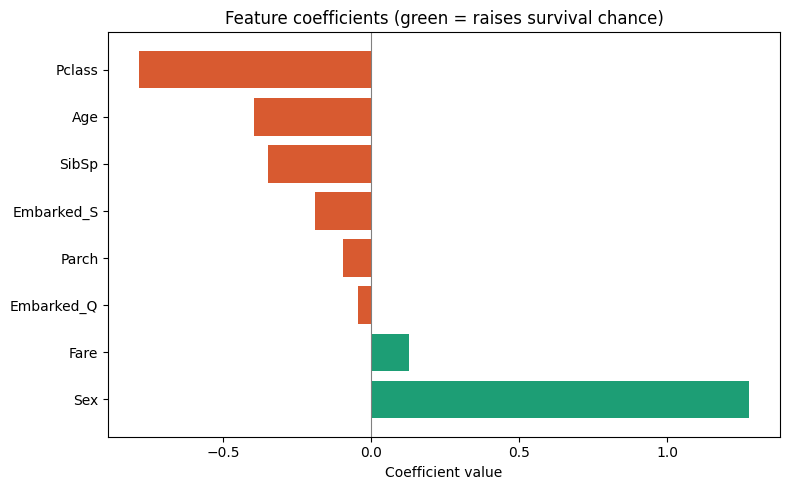


── Submission file created ─────────────
Rows : 418  (should be 418)
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0

Value counts:
Survived
0    261
1    157
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# ── 1. LOAD DATA ──────────────────────────────────────────
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("\nMissing values in train:")
print(train_df.isnull().sum())


# ── 2. HANDLE MISSING VALUES ──────────────────────────────
train_df["Age"] = train_df["Age"].fillna(train_df["Age"].median())
test_df["Age"] = test_df["Age"].fillna(train_df["Age"].median())

test_df["Fare"] = test_df["Fare"].fillna(train_df["Fare"].median())

train_df["Embarked"] = train_df["Embarked"].fillna(
    train_df["Embarked"].mode()[0]
)
test_df["Embarked"] = test_df["Embarked"].fillna(
    train_df["Embarked"].mode()[0]
)

# ── 3. DROP USELESS COLUMNS ───────────────────────────────
drop_cols = ["Cabin", "Name", "Ticket"]
train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols, inplace=True)

# ── 4. ENCODE CATEGORICAL COLUMNS ────────────────────────
train_df["Sex"] = train_df["Sex"].map({"male": 0, "female": 1})
test_df["Sex"]  = test_df["Sex"].map({"male": 0, "female": 1})

train_df = pd.get_dummies(train_df, columns=["Embarked"], drop_first=True)
test_df  = pd.get_dummies(test_df,  columns=["Embarked"], drop_first=True)

# Align columns (test may be missing a dummy column)
test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

# ── 5. SPLIT FEATURES AND TARGET ──────────────────────────
X = train_df.drop(columns=["PassengerId", "Survived"])
y = train_df["Survived"]
X_test_final = test_df.drop(columns=["PassengerId", "Survived"],
                             errors="ignore")

# ── 6. TRAIN / VALIDATION SPLIT ───────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── 7. SCALE FEATURES ────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test_final)

# ── 8. TRAIN MODEL ────────────────────────────────────────
model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train_sc, y_train)

# ── 9. EVALUATE ───────────────────────────────────────────
y_pred = model.predict(X_val_sc)

print("\n── Model Performance ──────────────────")
print(f"Validation Accuracy : {accuracy_score(y_val, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred,
      target_names=["Did not survive", "Survived"]))

# ── 10. FEATURE IMPORTANCE ───────────────────────────────
coeff_df = pd.DataFrame({
    "Feature":     X.columns,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient", ascending=False)

plt.figure(figsize=(8, 5))
colors = ["#1D9E75" if c > 0 else "#D85A30"
          for c in coeff_df["Coefficient"]]
plt.barh(coeff_df["Feature"], coeff_df["Coefficient"], color=colors)
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("Feature coefficients (green = raises survival chance)")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()

# ── 11. MAKE PREDICTIONS ON TEST SET ─────────────────────
predictions = model.predict(X_test_sc)

# ── 12. CREATE SUBMISSION FILE ───────────────────────────
submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived":    predictions
})
submission.to_csv("submission.csv", index=False)

print("\n── Submission file created ─────────────")
print(f"Rows : {len(submission)}  (should be 418)")
print(submission.head(10))
print("\nValue counts:")
print(submission["Survived"].value_counts())

In [ ]:
files.download('submission.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>